# EDA: comparing filtered SPX data across quarters

Loads the four `max_*` filtered files (one day per quarter, all filtered with the
same `FilterCriteria` in `src/filter_options.py`) and compares them side by side.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("../data")

FILES = {
    "Q1 (2023-01-04)": DATA_DIR / "Q1" / "max_spx_options_filtered_2023-01-04.csv",
    "Q2 (2023-06-30)": DATA_DIR / "Q2" / "max_spx_options_filtered_2023-06-30.csv",
    "Q3 (2023-08-15)": DATA_DIR / "Q3" / "max_spx_options_filtered_2023-08-15.csv",
    "Q4 (2023-11-14)": DATA_DIR / "Q4" / "max_spx_options_filtered_2023-11-14.csv",
}

frames = []
for label, path in FILES.items():
    df = pd.read_csv(path)
    df["quarter"] = label
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data["moneyness"] = data["strike"] / data["underlying_last"]
data.groupby("quarter").size()

quarter
Q1 (2023-01-04)     9604
Q2 (2023-06-30)    10242
Q3 (2023-08-15)    10082
Q4 (2023-11-14)     9298
dtype: int64

## Row counts and underlying level

All four days went through the same filter (`bid > 0`, `iv <= 100%`, moneyness in
`[0.75, 1.25]`, `dte <= 365`), so differences below come from the market on that
day, not from inconsistent cleaning.

In [2]:
summary = data.groupby("quarter").agg(
    rows=("strike", "size"),
    underlying=("underlying_last", "first"),
    calls=("option_type", lambda s: (s == "call").sum()),
    puts=("option_type", lambda s: (s == "put").sum()),
)
summary

,rows,underlying,calls,puts
quarter,,,,
Q1 (2023-01-04),9604,3853.39,4816,4788
Q2 (2023-06-30),10242,4450.23,5523,4719
Q3 (2023-08-15),10082,4438.11,5716,4366
Q4 (2023-11-14),9298,4496.43,3846,5452


## Implied volatility by quarter

Overlaid histograms, split by option type, show where each day's vol level and
skew sit relative to the others.

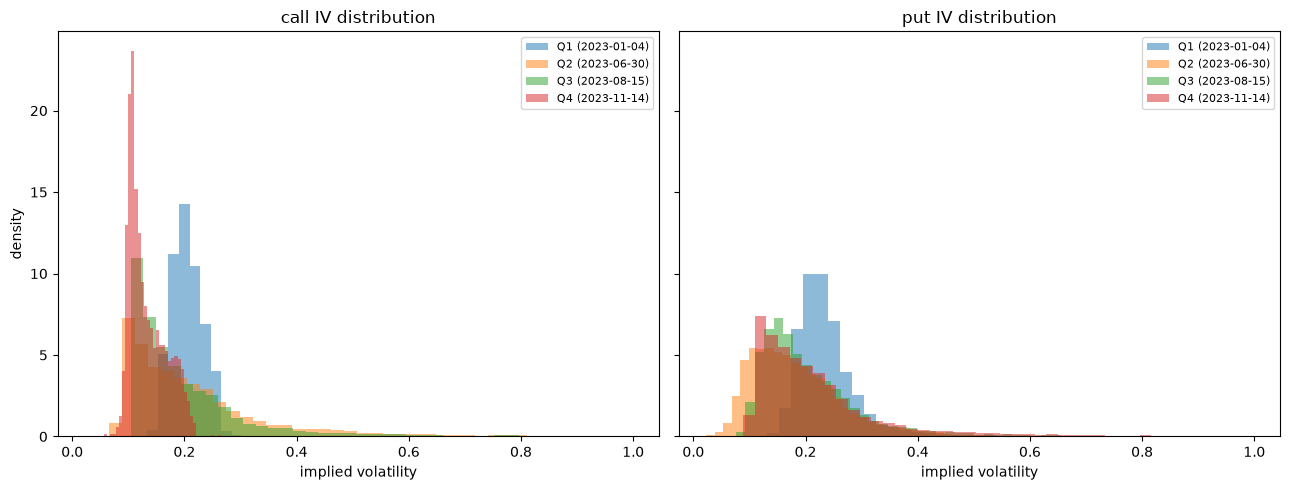

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, opt_type in zip(axes, ["call", "put"]):
    for label in FILES:
        subset = data[(data["quarter"] == label) & (data["option_type"] == opt_type)]
        ax.hist(subset["iv"], bins=40, alpha=0.5, label=label, density=True)
    ax.set_title(f"{opt_type} IV distribution")
    ax.set_xlabel("implied volatility")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.tight_layout()

## DTE and moneyness distributions

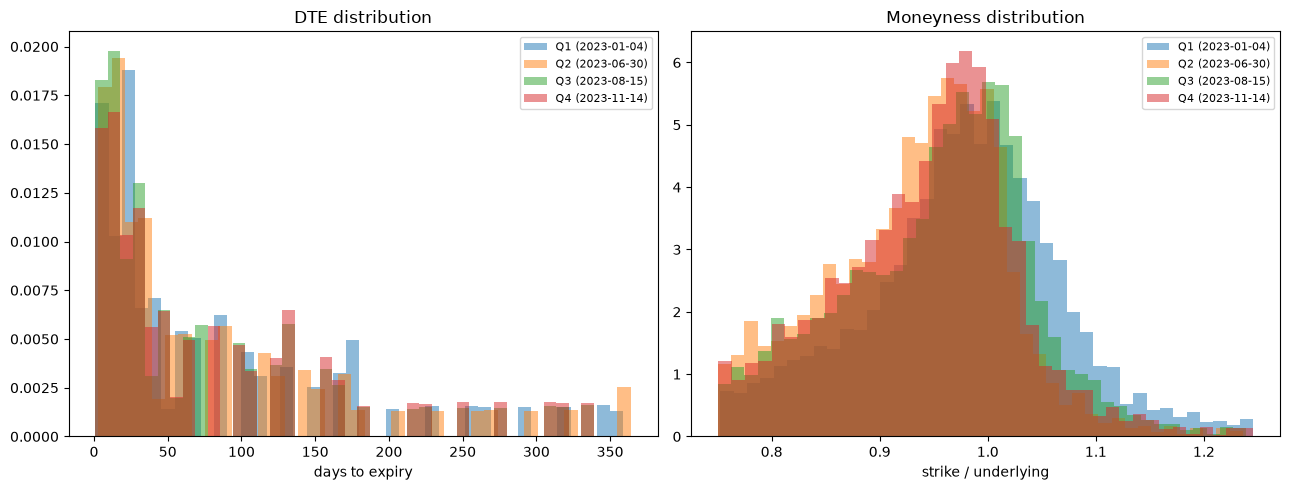

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label in FILES:
    subset = data[data["quarter"] == label]
    axes[0].hist(subset["dte"], bins=40, alpha=0.5, label=label, density=True)
    axes[1].hist(subset["moneyness"], bins=40, alpha=0.5, label=label, density=True)
axes[0].set_title("DTE distribution")
axes[0].set_xlabel("days to expiry")
axes[0].legend(fontsize=8)
axes[1].set_title("Moneyness distribution")
axes[1].set_xlabel("strike / underlying")
axes[1].legend(fontsize=8)
fig.tight_layout()

## Median IV by moneyness bucket and DTE bucket

A coarse, binned view of the vol surface shape for each day, so skew and term
structure differences are readable without a full 3D surface fit.

In [5]:
data["moneyness_bucket"] = pd.cut(data["moneyness"], bins=[0.75, 0.9, 0.97, 1.03, 1.1, 1.25])
data["dte_bucket"] = pd.cut(data["dte"], bins=[0, 7, 30, 90, 180, 365])

pivot = data.pivot_table(
    index="moneyness_bucket", columns="quarter", values="iv", aggfunc="median", observed=True
)
pivot

quarter,Q1 (2023-01-04),Q2 (2023-06-30),Q3 (2023-08-15),Q4 (2023-11-14)
moneyness_bucket,,,,
"(0.75, 0.9]",0.265085,0.265570,0.277860,0.238200
"(0.9, 0.97]",0.229390,0.179185,0.197555,0.165940
"(0.97, 1.03]",0.207165,0.111420,0.143000,0.117800
"(1.03, 1.1]",0.187160,0.104940,0.117080,0.110715
"(1.1, 1.25]",0.174840,0.112380,0.115730,0.113065


In [6]:
pivot_dte = data.pivot_table(
    index="dte_bucket", columns="quarter", values="iv", aggfunc="median", observed=True
)
pivot_dte

quarter,Q1 (2023-01-04),Q2 (2023-06-30),Q3 (2023-08-15),Q4 (2023-11-14)
dte_bucket,,,,
"(0, 7]",0.19188,0.22853,0.192475,0.220730
"(7, 30]",0.20688,0.15429,0.159160,0.133480
"(30, 90]",0.21751,0.17342,0.178070,0.139565
"(90, 180]",0.22810,0.17890,0.177830,0.168960
"(180, 365]",0.23480,0.18408,0.195000,0.173540


## Volume and spread

In [7]:
data["mid"] = (data["bid"] + data["ask"]) / 2
data["spread_pct"] = (data["ask"] - data["bid"]) / data["mid"]

liquidity = data.groupby("quarter").agg(
    median_volume=("volume", "median"),
    zero_volume_pct=("volume", lambda s: (s == 0).mean() * 100),
    median_spread_pct=("spread_pct", "median"),
    p90_spread_pct=("spread_pct", lambda s: s.quantile(0.9)),
)
liquidity

,median_volume,zero_volume_pct,median_spread_pct,p90_spread_pct
quarter,,,,
Q1 (2023-01-04),2.0,23.906706,0.014632,0.067416
Q2 (2023-06-30),3.0,17.457528,0.028040,0.113208
Q3 (2023-08-15),2.0,27.226741,0.016292,0.095238
Q4 (2023-11-14),3.0,22.047752,0.020481,0.105263


## Unified implied volatility (put-call parity + bisection)

Each strike has two quotes, a call and a put, that should each imply roughly the
same volatility. This section blends them into one "unified" price per strike
before solving for a single IV, instead of trusting either side alone.

**Step 1: mid prices.** For each strike, take the midpoint of each side's bid and ask.

$$
C_{mid} = \frac{C_{bid} + C_{ask}}{2}, \qquad P_{mid} = \frac{P_{bid} + P_{ask}}{2}
$$

**Step 2: parity-implied call price.** Put-call parity says a call and a put on
the same strike and expiry are linked through the forward value of the strike.
Solving that relationship for the call gives a second, independent estimate of
the call price, built entirely from the put's quote.

$$
C_{parity} = P_{mid} + S e^{-qT} - K e^{-rT}
$$

where $S$ is the underlying price, $K$ the strike, $T$ the time to expiry in
years, $r$ the risk-free rate, and $q$ the dividend yield. This notebook
currently uses a flat $r = 5\%$ and $q = 0\%$ for every quote, not a rate fit to
each specific day.

**Step 3: unified price.** Average the two call price estimates. This damps
quote noise on either side, since $C_{mid}$ and $C_{parity}$ are unlikely to be
wrong in the same direction.

$$
C_{unified} = \frac{C_{mid} + C_{parity}}{2}
$$

**Step 4: solve for volatility.** Find the $\sigma$ that makes the Black-Scholes
call price equal to $C_{unified}$, using bisection search over $\sigma$.

$$
C_{BS}(\sigma) = S e^{-qT} \Phi(d_1) - K e^{-rT} \Phi(d_2)
$$

$$
d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

$$
\text{solve for } \sigma \text{ such that } C_{BS}(\sigma) - C_{unified} = 0
$$

The bisection brackets $\sigma \in [10^{-6}, 5.0]$ (up to 500% vol) and stops once
the price error is under a small tolerance, or returns `NaN` if $C_{unified}$
falls outside the no-arbitrage bounds $[\max(S e^{-qT} - K e^{-rT}, 0),\ S e^{-qT}]$.

In [8]:
import numpy as np
from scipy.stats import norm


def black_scholes_call(spot, strike, time_to_expiry, volatility, rate, dividend):
    """Return the Black-Scholes European call price."""
    if time_to_expiry <= 0:
        return max(spot - strike, 0.0)

    volatility_sqrt_time = volatility * np.sqrt(time_to_expiry)
    d1 = (
        np.log(spot / strike)
        + (rate - dividend + 0.5 * volatility ** 2) * time_to_expiry
    ) / volatility_sqrt_time
    d2 = d1 - volatility_sqrt_time

    return (
        spot * np.exp(-dividend * time_to_expiry) * norm.cdf(d1)
        - strike * np.exp(-rate * time_to_expiry) * norm.cdf(d2)
    )


def implied_volatility_bisection(
    target_price,
    spot,
    strike,
    time_to_expiry,
    rate,
    dividend,
    lower_volatility=1e-6,
    upper_volatility=5.0,
    tolerance=1e-6,
    max_iterations=100,
):
    """Solve for call IV with bisection; return NaN if no valid bracket exists."""
    values = [target_price, spot, strike, time_to_expiry]
    if any(pd.isna(value) for value in values) or time_to_expiry <= 0:
        return np.nan

    discounted_spot = spot * np.exp(-dividend * time_to_expiry)
    discounted_strike = strike * np.exp(-rate * time_to_expiry)
    no_arbitrage_lower_bound = max(discounted_spot - discounted_strike, 0.0)
    no_arbitrage_upper_bound = discounted_spot

    if target_price < no_arbitrage_lower_bound - tolerance:
        return np.nan
    if target_price > no_arbitrage_upper_bound + tolerance:
        return np.nan

    low = lower_volatility
    high = upper_volatility
    low_price = black_scholes_call(spot, strike, time_to_expiry, low, rate, dividend)
    high_price = black_scholes_call(spot, strike, time_to_expiry, high, rate, dividend)

    if target_price < low_price - tolerance or target_price > high_price + tolerance:
        return np.nan

    for _ in range(max_iterations):
        midpoint = (low + high) / 2
        midpoint_price = black_scholes_call(
            spot, strike, time_to_expiry, midpoint, rate, dividend
        )
        price_error = midpoint_price - target_price

        if abs(price_error) < tolerance:
            return midpoint
        if price_error < 0:
            low = midpoint
        else:
            high = midpoint

    return (low + high) / 2

### Pair calls and puts, compute the unified price

Each quarter's `max_*` file has one row per contract (`option_type` is `call` or
`put`). Put-call parity needs both sides of the same strike/expiry, so this pairs
them on `(quarter, strike, expire_date)` before building the parity price.

In [9]:
risk_free_rate = 0.05
dividend_yield = 0.00

calls = data[data["option_type"] == "call"]
puts = data[data["option_type"] == "put"]

pairs = calls.merge(
    puts,
    on=["quarter", "strike", "expire_date", "underlying_last", "dte"],
    suffixes=("_call", "_put"),
)

pairs["call_mid"] = (pairs["bid_call"] + pairs["ask_call"]) / 2
pairs["put_mid"] = (pairs["bid_put"] + pairs["ask_put"]) / 2
pairs["time_to_expiry"] = pairs["dte"] / 365

pairs["parity_call_mid"] = (
    pairs["put_mid"]
    + pairs["underlying_last"] * np.exp(-dividend_yield * pairs["time_to_expiry"])
    - pairs["strike"] * np.exp(-risk_free_rate * pairs["time_to_expiry"])
)
pairs["unified_call_price"] = (pairs["call_mid"] + pairs["parity_call_mid"]) / 2
pairs["moneyness"] = pairs["strike"] / pairs["underlying_last"]

pairs[["call_mid", "put_mid", "parity_call_mid", "unified_call_price"]].describe()

,call_mid,put_mid,parity_call_mid,unified_call_price
count,16237.000000,16237.000000,16237.000000,16237.000000
mean,345.548871,62.561081,355.271692,350.410281
std,294.862270,75.650366,298.534267,296.643798
min,0.075000,0.075000,1.257354,0.791177
25%,107.050000,10.150000,113.832331,110.479853
50%,252.450000,34.800000,262.496071,257.476766
75%,527.450000,86.850000,540.542588,533.602248
max,1267.050000,606.850000,1312.008353,1289.529176


### Solve for unified IV

In [10]:
pairs["unified_iv"] = pairs.apply(
    lambda row: implied_volatility_bisection(
        target_price=row["unified_call_price"],
        spot=row["underlying_last"],
        strike=row["strike"],
        time_to_expiry=row["time_to_expiry"],
        rate=risk_free_rate,
        dividend=dividend_yield,
    ),
    axis=1,
)

valid_iv = pairs["unified_iv"].notna()
print(f"Valid unified IV observations: {valid_iv.sum():,} / {len(pairs):,}")
print(f"Valid IV percentage: {valid_iv.mean():.1%}")
pairs.groupby("quarter")["unified_iv"].describe()

Valid unified IV observations: 15,824 / 16,237
Valid IV percentage: 97.5%


,count,mean,std,min,25%,50%,75%,max
quarter,,,,,,,,
Q1 (2023-01-04),4001.0,0.217597,0.023974,0.118836,0.201730,0.213951,0.231643,0.479223
Q2 (2023-06-30),4429.0,0.173455,0.064754,0.058347,0.125163,0.162563,0.210431,0.562484
Q3 (2023-08-15),4318.0,0.216195,0.108524,0.114148,0.151742,0.185635,0.240059,1.020774
Q4 (2023-11-14),3076.0,0.152377,0.035076,0.101701,0.122523,0.144412,0.179116,0.389437


### Unified IV vs vendor IV, by quarter

`unified_iv` is solved from the parity-blended price; `iv_call` is the vendor's
own call IV for the same row. Close agreement is a sanity check on the bisection
and the `time_to_expiry` fix above.

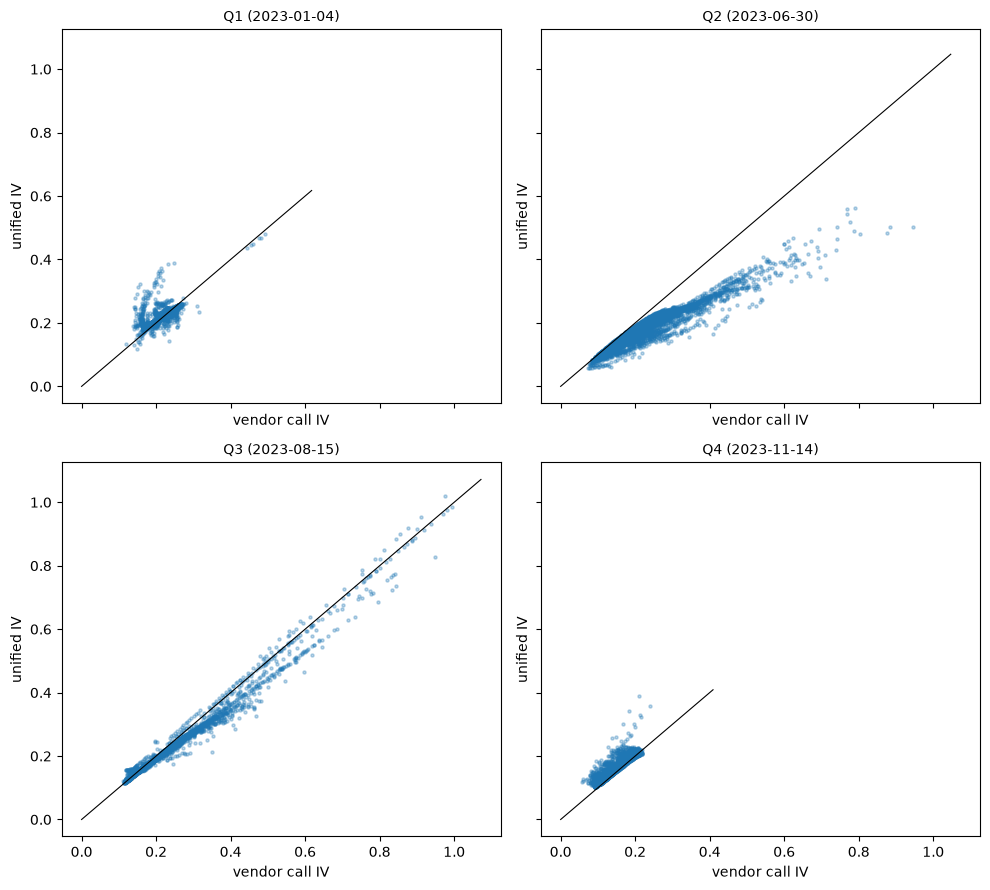

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, label in zip(axes.flat, FILES):
    subset = pairs[pairs["quarter"] == label]
    ax.scatter(subset["iv_call"], subset["unified_iv"], s=5, alpha=0.3)
    lims = [0, subset[["iv_call", "unified_iv"]].max().max() * 1.05]
    ax.plot(lims, lims, color="black", linewidth=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("vendor call IV")
    ax.set_ylabel("unified IV")
fig.tight_layout()

### Unified IV surface, discrete points

Plotting the observed `(moneyness, DTE, unified_iv)` points directly, no interpolation between them.

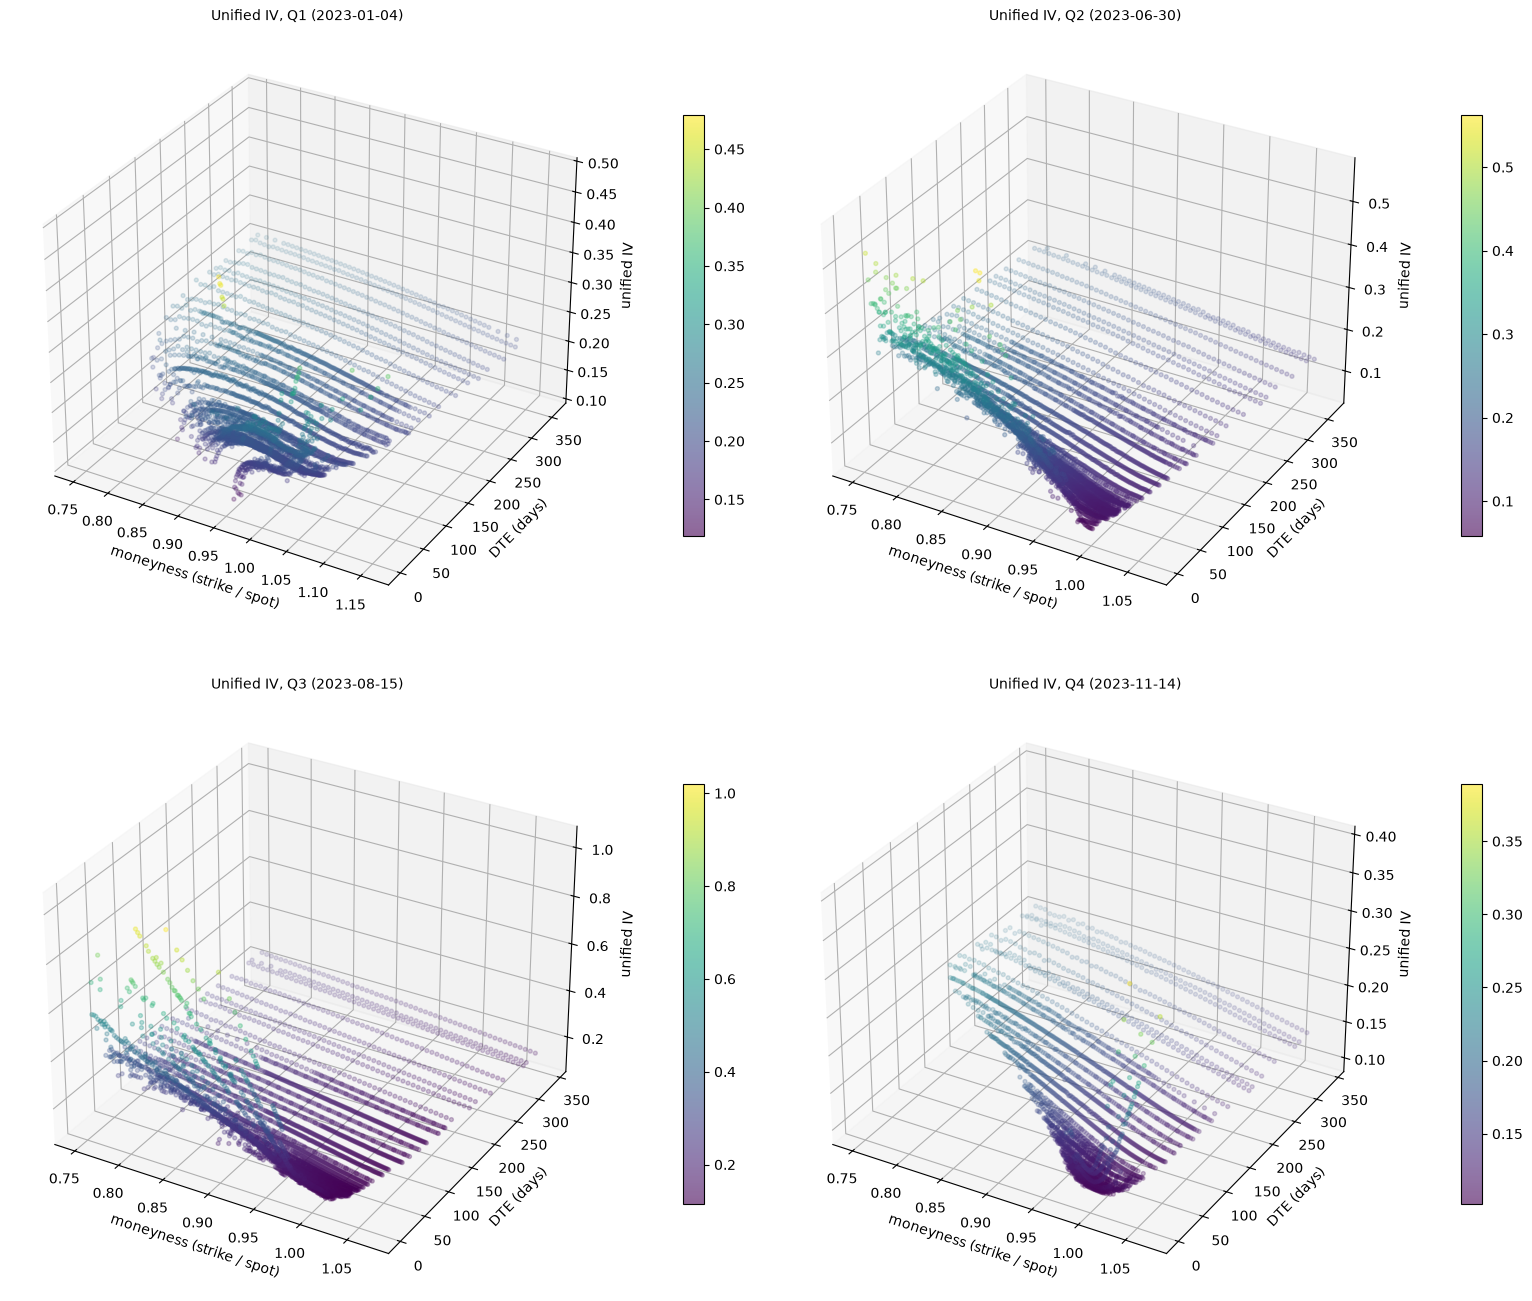

In [12]:
fig = plt.figure(figsize=(16, 14))
for i, label in enumerate(FILES):
    surface = pairs[pairs["quarter"] == label].dropna(
        subset=["moneyness", "dte", "unified_iv"]
    )
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    scatter = ax.scatter(
        surface["moneyness"],
        surface["dte"],
        surface["unified_iv"],
        c=surface["unified_iv"],
        cmap="viridis",
        s=8,
        alpha=0.6,
    )
    ax.set_title(f"Unified IV, {label}", fontsize=10)
    ax.set_xlabel("moneyness (strike / spot)")
    ax.set_ylabel("DTE (days)")
    ax.set_zlabel("unified IV")
    fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
fig.tight_layout()